In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("../data_raw/train.csv")
df.head()


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


In [6]:
def extract_num(series):
    return series.astype(str).str.extract(r'([\d.]+)', expand=False).astype(float)

for col in ["Mileage", "Engine", "Power", "New_Price"]:
    if col in df.columns:
        df[col] = extract_num(df[col])


In [7]:
num_cols = ["Mileage","Engine","Power","New_Price","Kilometers_Driven"]
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

cat_cols = ["Fuel_Type","Transmission"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])


In [8]:
df_encoded = pd.get_dummies(df, columns=["Fuel_Type","Transmission"], drop_first=True)
df_encoded.head()


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Fuel_Type_Electric,Fuel_Type_Petrol,Transmission_Manual
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,First,19.67,1582.0,126.20,5.0,11.48,12.50,False,False,True
1,2,Honda Jazz V,Chennai,2011,46000,First,13.00,1199.0,88.70,5.0,8.61,4.50,False,True,True
2,3,Maruti Ertiga VDI,Chennai,2012,87000,First,20.77,1248.0,88.76,7.0,11.48,6.00,False,False,True
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Second,15.20,1968.0,140.80,5.0,11.48,17.74,False,False,False
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,First,23.08,1461.0,63.10,5.0,11.48,3.50,False,False,True


In [9]:
df_encoded["Car_Age"] = 2024 - df_encoded["Year"]


In [10]:
# select
df_select = df_encoded[["Price","Mileage","Engine","Car_Age"]]

# filter
df_filter = df_encoded[df_encoded["Car_Age"] < 10]

# rename
df_rename = df_encoded.rename(columns={"Price": "Used_Car_Price"})

# mutate
df_encoded["Price_per_km"] = df_encoded["Price"] / df_encoded["Kilometers_Driven"]

# arrange
df_sorted = df_encoded.sort_values(by="Price", ascending=False)

# summarize
avg_price_by_fuel = df_encoded.groupby("Fuel_Type_Petrol")["Price"].mean()
avg_price_by_fuel


Fuel_Type_Petrol
False    12.960632
True      5.756688
Name: Price, dtype: float64

In [11]:
df_encoded.to_csv("../data_clean/used_cars_clean.csv", index=False)


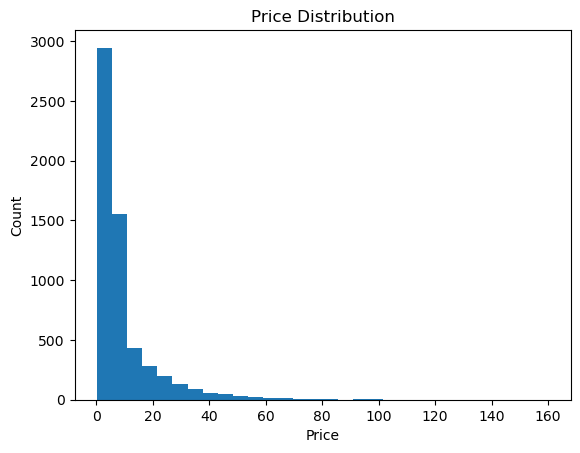

In [12]:
plt.figure()
plt.hist(df_encoded["Price"], bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.savefig("../results/q1_price_histogram.png")
plt.show()


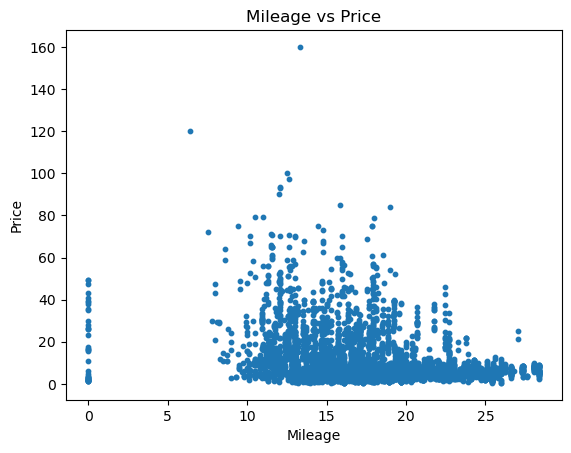

In [13]:
plt.figure()
plt.scatter(df_encoded["Mileage"], df_encoded["Price"], s=10)
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")
plt.savefig("../results/q1_price_vs_mileage.png")
plt.show()
